# Example 2: Ruin Probability with Pareto Claims
In this notebook, example 2 of the thesis is implemented.
The claim distribution is a Pareto law, i.e. heavy tailed.


In [1]:
import sys
import os

# Add the parent directory to sys.path so we can import our src modules
sys.path.append(os.path.abspath('../'))

import mpmath, matplotlib.pyplot as plt
from tqdm import tqdm # for measuring progress

from src.talbot import talbot_method_abate
from src.laplace_transforms import lapl_psi, lapl_psi_1, lapl_psi_2, lapl_pareto
from src.utils import print_results, residue, in_contour

In [2]:
# Set global precision
M = 60
ctx = mpmath.mp
ctx.dps = M

 ## Parameter Setup

In [3]:
lmbda = ctx.mpf('1')          # Intensity of claims
c = ctx.mpf('1')              # Premium rate
sigmasq = ctx.mpf('0.4')      # Variance of diffusion term
mu = ctx.fraction('21', '36') # Mean of claims

q = (c - lmbda * mu) / c      # Realtive security loading
zeta = 2 * c / sigmasq

x_min = ctx.fraction('7', '36')
alpha = ctx.fraction('3', '2')

## Look for poles of lapl_psi
Here we find (approximate) solutions equation (4.1) from the thesis, meaning poles of $\mathcal{L}(\psi)$.

In [4]:
# --- Search poles --- #
solutions = list()
# find solutions of F = 0
def F(s):
    return s + ctx.fraction('1','5') * s ** 2 - ctx.mpf('1') + lapl_pareto(s, ctx, alpha, x_min)

# Grid of points in upper half plane
grid = [ctx.mpc(x, y) for x in ctx.linspace(-100, 5, 20) for y in ctx.linspace(10, 500, 50)]
print("finding singularities...")
for z in tqdm(grid):
    try:
        root = ctx.findroot(F, z)
        solutions.append(root)
    except: # If no root near z -> catch error
        pass
# Remove redundant solutions and solutions close to 0
unique_solutions = [solutions[0]]

for i in range(1, len(solutions)):
    candidate = solutions[i]
    distances = [abs(s - candidate) for s in unique_solutions]
    if min(distances) > 1e-5 and abs(candidate) > 1e-5:
        unique_solutions.append(candidate)

finding singularities...


100%|██████████| 1000/1000 [02:41<00:00,  6.20it/s]


Approximate Singularities:
(-29.88104822 + 3.94620942j)
(-44.44564101 + 45.95096847j)
(-51.16368515 + 81.0665581j)
(-55.76620254 + 114.8882546j)
(-59.29315104 + 148.1714095j)
(-62.15857454 + 181.1697073j)
(-64.57358573 + 213.9964776j)
(-66.66137781 + 246.710979j)
(-68.50039493 + 279.3475464j)
(-70.14377136 + 311.9275827j)
(-71.62920537 + 344.4651852j)
(-72.98442937 + 376.9700492j)
(-74.23044719 + 409.4490784j)
(-75.38355242 + 441.9073326j)
(-76.45664123 + 474.3486105j)
(-77.46009683 + 506.7758234j)


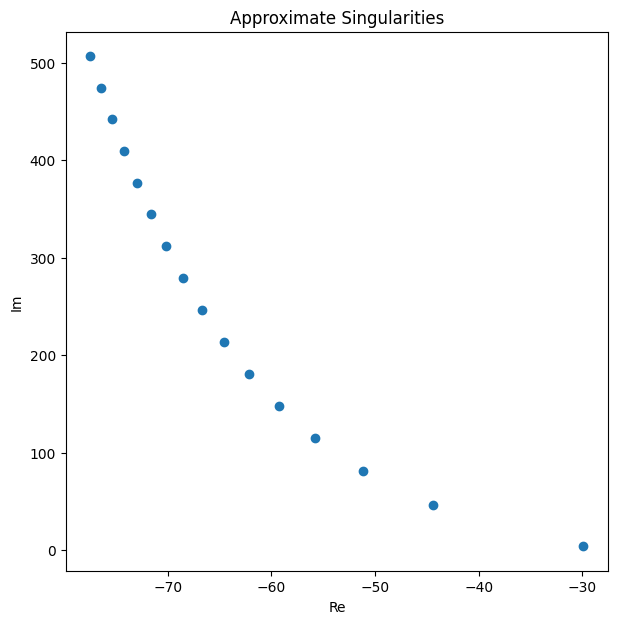

In [5]:
# --- display results --- #
print_results([unique_solutions], "Approximate Singularities:")

plt.figure(figsize=(7, 7))
plt.plot([z.real for z in unique_solutions], [z.imag for z in unique_solutions], 'o')
plt.xlabel("Re")
plt.ylabel("Im")
plt.title("Approximate Singularities")
plt.show()

Now we approximate the residues at the singularities.

In [7]:
num_sing = len(unique_solutions)
residues_raw_direct, residues_raw_1, residues_raw_2 = [0] * num_sing, [0] * num_sing, [0] * num_sing

print("Computing residues...")
for i, z in tqdm(enumerate(unique_solutions), total=len(unique_solutions)):
    residues_raw_direct[i] = residue(lapl_psi, z,
                                     lmbda=lmbda,
                                     q=q,
                                     c=c,
                                     zeta=zeta,
                                     lapl_X_func=lapl_pareto,
                                     alpha=alpha,
                                     x_min=x_min)
print("Computing residues for oscillation...")
for i, z in tqdm(enumerate(unique_solutions), total=len(unique_solutions)):
    residues_raw_1[i] = residue(lapl_psi_1, z,
                                lmbda=lmbda,
                                c=c,
                                sigmasq=sigmasq,
                                lapl_X_func=lapl_pareto,
                                alpha=alpha,
                                x_min=x_min)
print("Computing residues for claims...")
for i, z in tqdm(enumerate(unique_solutions), total=len(unique_solutions)):
    residues_raw_2[i] = residue(lapl_psi_2, z,
                                lmbda=lmbda,
                                mu=mu,
                                c=c,
                                sigmasq=sigmasq,
                                lapl_X_func=lapl_pareto,
                                alpha=alpha,
                                x_min=x_min)

def Fprime(s):
  return c + sigmasq * s - lmbda * alpha * x_min**alpha * s ** (alpha - 1) * ctx.gammainc(- alpha - 1, s * x_min)

Fprime_values = [Fprime(s) for s in unique_solutions]


Computing residues...


100%|██████████| 16/16 [00:40<00:00,  2.53s/it]


Computing residues for oscillation...


100%|██████████| 16/16 [00:35<00:00,  2.22s/it]


Computing residues for claims...


100%|██████████| 16/16 [00:35<00:00,  2.25s/it]


In [8]:
print_results([unique_solutions, Fprime_values, residues_raw_direct, residues_raw_1, residues_raw_2],
              "Singularity\t\tFprime value\t\tRes(psi)\t\tRes(psi1)\t\tRes(psi2)", 4)

Singularity		Fprime value		Res(psi)		Res(psi1)		Res(psi2)
(-29.88 + 3.946j)	(-9.967 + 1.809j)	(-0.02197 - 0.0212j)	(-0.3553 - 0.2624j)	(0.3333 + 0.2412j)
(-44.45 + 45.95j)	(-15.76 + 18.41j)	(0.001024 - 0.003036j)	(-0.04512 - 0.08735j)	(0.04614 + 0.08432j)
(-51.16 + 81.07j)	(-18.44 + 32.44j)	(0.0007744 - 0.001026j)	(-0.0209 - 0.05533j)	(0.02168 + 0.0543j)
(-55.77 + 114.9j)	(-20.28 + 45.96j)	(0.0005101 - 0.000475j)	(-0.01254 - 0.04084j)	(0.01305 + 0.04037j)
(-59.29 + 148.2j)	(-21.69 + 59.27j)	(0.000352 - 0.0002604j)	(-0.008502 - 0.03245j)	(0.008854 + 0.03219j)
(-62.16 + 181.2j)	(-22.84 + 72.47j)	(0.0002553 - 0.0001589j)	(-0.006201 - 0.02694j)	(0.006457 + 0.02678j)
(-64.57 + 214.0j)	(-23.8 + 85.6j)	(0.0001928 - 0.0001044j)	(-0.004751 - 0.02304j)	(0.004944 + 0.02294j)
(-66.66 + 246.7j)	(-24.64 + 98.69j)	(0.0001504 - 7.249e-5j)	(-0.003771 - 0.02013j)	(0.003922 + 0.02006j)
(-68.5 + 279.3j)	(-25.37 + 111.7j)	(0.0001205 - 5.247e-5j)	(-0.003075 - 0.01788j)	(0.003196 + 0.01782j)
(-70.14 + 311.9j

## Compute probabilities
Finally, we may approximate the probabilities, by using the residues computed above.

In [9]:
# --- Compute some probabilities --- #
u_values = range(1, 11)
print("computing approximations...")
approx_values = [talbot_method_abate(lapl_psi,
                                     u,
                                     60,
                                     lmbda=lmbda,
                                     q=q,
                                     c=c,
                                     zeta=zeta,
                                     lapl_X_func=lapl_pareto,
                                     alpha=alpha,
                                     x_min=x_min) for u in tqdm(u_values)]

approx_oscillation = [talbot_method_abate(lapl_psi_1,
                                          u,
                                          60,
                                          lmbda=lmbda,
                                          c=c,
                                          sigmasq=sigmasq,
                                          lapl_X_func=lapl_pareto,
                                          alpha=alpha,
                                          x_min=x_min) for u in tqdm(u_values)]

approx_claim = [talbot_method_abate(lapl_psi_2,
                                    u,
                                    60,
                                    lmbda=lmbda,
                                    mu=mu,
                                    c=c,
                                    sigmasq=sigmasq,
                                    lapl_X_func=lapl_pareto,
                                    alpha=alpha,
                                    x_min=x_min) for u in tqdm(u_values)]

approx_mix = [approx_oscillation[i] + approx_claim[i] for i in range(len(u_values))]

# Compute compensators
compensators_direct = []
compensators_1 = []
compensators_2 = []

for u in u_values:
    r = ctx.fraction('2', '5') * M / u

    comp, comp1, comp2 = 0, 0, 0

    for s_k, res, res1, res2 in zip(unique_solutions, residues_raw_direct, residues_raw_1, residues_raw_2):
      if not in_contour(s_k, r): # If singularity is not inside contour -> influences compensator
        comp += res * ctx.exp(s_k * u)
        comp1 += res1 * ctx.exp(s_k * u)
        comp2 += res2 * ctx.exp(s_k * u)

    compensators_direct.append(2 * comp.real)
    compensators_1.append(2 * comp1.real)
    compensators_2.append(2 * comp2.real)

approx_compensated = [approx_values[i] + compensators_direct[i] for i in range(len(u_values))]
approx_compensated_1 = [approx_oscillation[i] + compensators_1[i] for i in range(len(u_values))]
approx_compensated_2 = [approx_claim[i] + compensators_2[i] for i in range(len(u_values))]
approx_compensated_mix = [approx_compensated_1[i] + approx_compensated_2[i] for i in range(len(u_values))]

computing approximations...


100%|██████████| 10/10 [00:01<00:00,  9.00it/s]


## Display Results

In [10]:
print_results([[ctx.mpf(u) for u in u_values], approx_compensated, approx_compensated_mix, approx_compensated_1, approx_compensated_2],
               "u\tApprox (direct)\tApprox (mix)\tApprox (osc)\tApprox (claim)", 10)
print("="*70)
print_results([[ctx.mpf(u) for u in u_values], compensators_direct, compensators_1, compensators_2],
              "u\tCompensation\tCompen (osc)\tCompen (claim)", 5)

u	Approx (direct)	Approx (mix)	Approx (osc)	Approx (claim)
1.0	0.4126252677	0.4126252677	0.08984694052	0.3227783272
2.0	0.2960680928	0.2960680928	0.03533412843	0.2607339644
3.0	0.2414889847	0.2414889847	0.01956257482	0.2219264099
4.0	0.2086832113	0.2086832113	0.01272929974	0.1959539116
5.0	0.1862994436	0.1862994436	0.009093969927	0.1772054737
6.0	0.1698098082	0.1698098082	0.006902323473	0.1629074848
7.0	0.1570234403	0.1570234403	0.005465133956	0.1515583063
8.0	0.1467387977	0.1467387977	0.004464081148	0.1422747166
9.0	0.138236159	0.138236159	0.003734468299	0.1345016907
10.0	0.1310552067	0.1310552067	0.003183585906	0.1278716208
u	Compensation	Compen (osc)	Compen (claim)
1.0	5.3243e-27	-5.8514e-24	5.8568e-24
2.0	-1.433e-41	-1.5312e-40	1.3879e-40
3.0	-4.1143e-62	-1.8343e-59	1.8302e-59
4.0	3.7172e-80	1.0886e-78	-1.0514e-78
5.0	-1.3332e-99	3.515e-99	-4.8483e-99
6.0	-4.082e-119	-2.8388e-117	2.798e-117
7.0	4.887e-138	1.0089e-136	-9.6006e-137
8.0	-8.7348e-158	3.1532e-156	-3.2406e-156
9.0	-8.762